---
title: "Insurance Claim Modeling: TabPFN vs. GLM"
description: "Predict insurance pure premiums on zero-inflated claims data; TabPFN on the raw dataframe vs. hand-engineered actuarial GLM, with per-policy uncertainty"
icon: "car-burst"
cookbookTags:
  - regression
  - insurance
authors:
  - name: Philipp Singer
    linkedin: https://www.linkedin.com/in/philippsinger
    twitter: https://twitter.com/ph_singer
---

*Better risk ranking and per-policy uncertainty from the raw dataframe, no feature engineering.*

Insurance claim data is *zero-inflated*: most policies never claim, and the few that do produce
heavily right-skewed amounts. Pricing it well is the core actuarial problem, and the classic recipe
is a **two-stage generalized linear model (GLM)**: a frequency model (how often do claims happen?)
times a severity model (how large are they?). Making a GLM work takes real feature engineering, 
binning, one-hot encoding, log-scaling, and choosing link functions and a Tweedie power by hand.

[TabPFN](https://github.com/PriorLabs/TabPFN) is a tabular foundation model that learns in a single
forward pass with **no per-dataset training and no preprocessing**, you hand it the raw dataframe
(mixed numeric and string columns, missing values and all). This notebook puts TabPFN head-to-head
with matching scikit-learn GLM baselines on the standard French Motor Third-Party Liability
(freMTPL2) dataset. For both the GLM and TabPFN we run a **single-stage** direct model and a
**two-stage** decomposition. The GLM uses the classic frequency × per-claim severity recipe;
TabPFN uses its natural hurdle-model analogue, occurrence × conditional aggregate cost. Both target
the same quantity: expected annual claim cost.

**Bottom line up front:**

- **Better risk ranking, zero feature engineering.** Straight from the 9-column raw dataframe, TabPFN
  reaches an exposure-weighted **Gini of ~0.34 vs ~0.31** for the best hand-built GLM, better
  separation of safe from risky policies, which is what drives pricing.
- **A rich conditional cost distribution per policy.** Given that a claim occurs, TabPFN returns the
  expected cost and any quantile, with a shape that adapts per policy, handy for understanding the
  severity tail.
- **Calibration on par, with one optional adjustment.** A single portfolio-level rescale,
  estimated on held-out training data, brings TabPFN's Tweedie deviance close to the GLMs while
  leaving its stronger ranking untouched.

We score with the metrics actuaries actually use: the **exposure-weighted Gini** (ranking / lift) and
**Tweedie deviance / D²** (calibration, the standard loss for zero-inflated cost; both are
defined in the Metrics section below).

> **Requirements.** This notebook runs on the hosted TabPFN client (`tabpfn-client`), so no local GPU is
> needed; you just need a free API token (see the setup cells below). Baselines, dataset explanation and metrics follow scikit-learn's
> [Tweedie regression on insurance claims](https://scikit-learn.org/stable/auto_examples/linear_model/plot_tweedie_regression_insurance_claims.html) example which motivated this tutorial.


In [ ]:
!pip install tabpfn_client matplotlib scikit-learn

In [1]:
import warnings

# tabpfn-client warns that the full-output criterion needs the local tabpfn package; not needed here.
warnings.filterwarnings("ignore", message="Optional dependencies 'tabpfn' and 'torch'")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.preprocessing import (
    KBinsDiscretizer, OneHotEncoder, StandardScaler, FunctionTransformer,
)
from sklearn.linear_model import PoissonRegressor, GammaRegressor, TweedieRegressor
from sklearn.metrics import mean_tweedie_deviance, d2_tweedie_score, auc


# Benign numeric overflow in TabPFN's inverse target transform (expm1 on the far
# tail of the output distribution's support); results are unaffected.
warnings.filterwarnings("ignore", message="overflow encountered in exp")

RANDOM_STATE = 0
N_ESTIMATORS = 8
FEATURES = ["VehAge", "DrivAge", "VehBrand", "VehPower", "VehGas",
            "Region", "Area", "BonusMalus", "Density"]

In this notebook, we use the TabPFN client to access the API, so no hardware is required to run the model.

In [2]:
from tabpfn_client import TabPFNClassifier, TabPFNRegressor, get_access_token
token = get_access_token()

# uncomment for local version
# from tabpfn import TabPFNClassifier, TabPFNRegressor

## The data

Each row is an insurance **policy** — a contract between the insurer and a policyholder — described
by driver age, vehicle age, vehicle power, region, and so on. A **claim** is a request for
compensation; the **claim amount** is what the insurer pays out. **Exposure** is how long the policy
was actually observed, measured in years: a policy on the books for the full period has
`Exposure = 1.0`, one observed for six months has `Exposure ≈ 0.5`. It matters because a policy
watched for two months has had far less opportunity to claim than one watched all year, so every
rate below is expressed *per unit of exposure*.

Our target is the **pure premium**: the expected claim cost per unit of exposure, i.e., the
break-even price of the risk. There are two classic ways to model it:

- **Single-stage:** model the total claim cost per unit exposure directly.
- **Two-stage:** model the claim *frequency* (claims per year) and the *severity* (average amount per
  claim) separately, then multiply.

The column `reMTPL2freq` holds one row per policy (risk features, claim count `ClaimNb`, and `Exposure`), `freMTPL2sev` holds the individual claim amounts. We aggregate claim amounts per policy and join;
policies with no claim get `ClaimAmount = 0`. We apply the same light cleaning as the scikit-learn
example (cap extreme values, make `ClaimNb` consistent with `ClaimAmount`) and derive the targets
`Frequency = ClaimNb / Exposure`, `AvgClaimAmount = ClaimAmount / ClaimNb`, and
`PurePremium = ClaimAmount / Exposure`.

Note the feature columns: `VehBrand`, `VehGas`, `Region`, `Area` are **strings**, the rest are
numeric on very different scales. A GLM cannot consume this directly; TabPFN can.


In [3]:
freq = fetch_openml(data_id=41214, as_frame=True).frame   # policies: features + ClaimNb + Exposure
sev = fetch_openml(data_id=41215, as_frame=True).frame     # individual claim amounts

df = freq.copy()
df["ClaimAmount"] = df["IDpol"].map(sev.groupby("IDpol")["ClaimAmount"].sum()).fillna(0.0)

# Standard cleaning.
df["ClaimNb"] = df["ClaimNb"].clip(upper=4)
df["Exposure"] = df["Exposure"].clip(upper=1)
df["ClaimAmount"] = df["ClaimAmount"].clip(upper=200_000)
df.loc[(df["ClaimAmount"] == 0) & (df["ClaimNb"] >= 1), "ClaimNb"] = 0

# Insurance companies are interested in modeling the Pure Premium, that is
# the expected total claim amount per unit of exposure for each policyholder
# in their portfolio:
df["PurePremium"] = df["ClaimAmount"] / df["Exposure"]

# This can be indirectly approximated by a 2-step modeling: the product of the
# Frequency times the average claim amount per claim:
df["Frequency"] = df["ClaimNb"] / df["Exposure"]
df["AvgClaimAmount"] = df["ClaimAmount"] / np.fmax(df["ClaimNb"], 1)

zero = (df["ClaimAmount"] == 0).mean()
print(f"{len(df):,} policies | {100 * zero:.1f}% have ZERO claim amount | "
      f"{(df.ClaimAmount > 0).sum():,} claims")
df[FEATURES + ["Exposure", "ClaimNb", "ClaimAmount", "PurePremium", "Frequency", "AvgClaimAmount"]].sort_values("ClaimAmount", ascending=False).head()

678,013 policies | 96.3% have ZERO claim amount | 24,944 claims


,VehAge,DrivAge,VehBrand,VehPower,VehGas,Region,Area,BonusMalus,Density,Exposure,ClaimNb,ClaimAmount,PurePremium,Frequency,AvgClaimAmount
298185,5,31,B2,7,'Diesel',R24,B,51,60,0.42,1,200000.0,4.761905e+05,2.380952,200000.0
135927,12,27,B2,4,'Regular',R24,C,90,319,1.00,1,200000.0,2.000000e+05,1.000000,200000.0
75668,3,46,B1,6,'Diesel',R24,A,50,10,0.75,1,200000.0,2.666667e+05,1.333333,200000.0
231941,13,21,B1,4,'Diesel',R24,A,140,37,0.16,2,200000.0,1.250000e+06,12.500000,100000.0
568614,9,72,B1,5,'Diesel',R24,C,50,405,0.36,1,200000.0,5.555556e+05,2.777778,200000.0


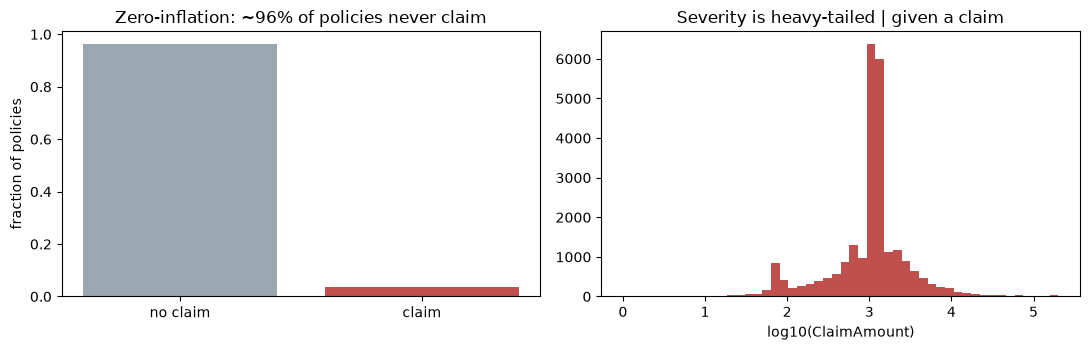

In [4]:
fig, ax = plt.subplots(1, 2, figsize=(11, 3.6))
ax[0].bar(["no claim", "claim"],
          [(df.ClaimAmount == 0).mean(), (df.ClaimAmount > 0).mean()],
          color=["#9aa7b0", "#c0504d"])
ax[0].set_ylabel("fraction of policies")
ax[0].set_title("Zero-inflation: ~96% of policies never claim")

pos = df.loc[df.ClaimAmount > 0, "ClaimAmount"]
ax[1].hist(np.log10(pos), bins=50, color="#c0504d")
ax[1].set_xlabel("log10(ClaimAmount)")
ax[1].set_title("Severity is heavy-tailed | given a claim")
plt.tight_layout()
plt.show()

We hold out 25% of policies for testing with a **random** split. A production pricing model would
usually be validated *out of time* (train on older policy years, test on newer) to catch drift, but
freMTPL2 ships without a usable time index, so we follow the scikit-learn example and split at
random; a simplification worth remembering for similar use cases.


In [5]:
df_train, df_test = train_test_split(df, test_size=0.25, random_state=RANDOM_STATE)
pp_true = df_test["PurePremium"].to_numpy()
weight = df_test["Exposure"].to_numpy()          # exposure-weighting for the metrics
print(f"train {len(df_train):,} | test {len(df_test):,}")

train 508,509 | test 169,504


## Metrics

Two questions matter for a pricing model, and they need different metrics.

**Ranking / lift — does the model sort safe from risky policies?** This is what segmentation and
pricing rely on, and our headline metric. We use the **exposure-weighted Gini**. Sort policies from
safest to riskiest by predicted premium, then trace the cumulative share of *actual* claim cost
against the cumulative share of exposure — the Lorenz curve $L(u)$. The Gini is (twice) the area
between that curve and the diagonal:

$$\mathrm{Gini} = 1 - 2\int_0^1 L(u)\,du$$

Higher is better; a model with no information scores 0. In code it is `1 - 2 * auc(cum_exposure,
cum_claims)`.

**Calibration — is the predicted premium level right?** We use the **Tweedie deviance** (lower is
better) and its normalized cousin **D²** (higher is better, an R²-style score), the standard loss for
zero-inflated, right-skewed cost targets. This is exactly the GLM's own training objective.

We deliberately skip MAE (degenerate on a 96%-zero target — it rewards predicting near-zero for
everyone) and RMSE (dominated by a handful of catastrophic claims).


In [6]:
def gini_exposure(y_true, y_pred, exposure):
    order = np.argsort(y_pred)                     # ascending: safest -> riskiest
    exp = np.asarray(exposure)[order]
    claim = np.asarray(y_true)[order] * exp
    cum_claim = np.cumsum(claim) / claim.sum()
    cum_exp = np.cumsum(exp) / exp.sum()
    return 1 - 2 * auc(cum_exp, cum_claim)

def scores(pred):
    pred = np.clip(pred, 1e-6, None)               # Tweedie deviance needs strictly positive
    return {
        "Gini (exposure)  up": gini_exposure(pp_true, pred, weight),
        "D2 (Tweedie 1.9)  up": d2_tweedie_score(pp_true, pred, sample_weight=weight, power=1.9),
        "Tweedie dev 1.9  down": mean_tweedie_deviance(pp_true, pred, sample_weight=weight, power=1.9),
        "Tweedie dev 1.5  down": mean_tweedie_deviance(pp_true, pred, sample_weight=weight, power=1.5),
    }

## GLM baselines

A GLM (generalized linear model) is a linear model with a link function — here a log link, so
predictions stay positive. Being linear, every feature has to be hand-engineered into a numeric
design matrix: bin the skewed numerics, one-hot the categoricals, log-and-scale the heavy-tailed one.
On that shared design matrix we fit the two classic recipes for the pure premium — a **single-stage**
direct Tweedie model, then the **two-stage** frequency × severity product.

The hyperparameters (Tweedie power, regularization strengths) are taken straight from the
scikit-learn tutorial and left untuned; in practice you would grid-search them. That cuts both ways
in this comparison — TabPFN is also run untuned, on its defaults.


### Single-stage GLM: direct Tweedie on pure premium

The simplest recipe: one `TweedieRegressor` fit straight on `PurePremium`, weighted by `Exposure`. No
occurrence/severity split — a single model for the whole target. We set `power=1.9` following the
scikit-learn tutorial.


In [7]:
def make_glm_preprocessor():
    # A fresh ColumnTransformer per model (so fitting one does not overwrite another).
    log_scale = make_pipeline(FunctionTransformer(np.log, validate=False), StandardScaler())
    return ColumnTransformer([
        ("binned", KBinsDiscretizer(n_bins=10, random_state=RANDOM_STATE), ["VehAge", "DrivAge"]),
        ("onehot", OneHotEncoder(handle_unknown="ignore"),
         ["VehBrand", "VehPower", "VehGas", "Region", "Area"]),
        ("passthrough", "passthrough", ["BonusMalus"]),
        ("log_scaled", log_scale, ["Density"]),
    ], remainder="drop")

Xtr = df_train[FEATURES]
n_design = make_glm_preprocessor().fit_transform(Xtr).shape[1]
print(f"GLM design matrix: {n_design} engineered columns from {len(FEATURES)} raw features")

# Single-stage: a direct Tweedie model on the pure premium, weighted by exposure.
glm_tweedie = Pipeline([("prep", make_glm_preprocessor()),
                        ("reg", TweedieRegressor(power=1.9, alpha=0.1, max_iter=1000))])
glm_tweedie.fit(Xtr, df_train["PurePremium"], reg__sample_weight=df_train["Exposure"])
pp_glm_tweedie = glm_tweedie.predict(df_test[FEATURES])
scores(pp_glm_tweedie)

GLM design matrix: 75 engineered columns from 9 raw features


{'Gini (exposure)  up': 0.2883310924949033,
 'D2 (Tweedie 1.9)  up': 0.013734740755400598,
 'Tweedie dev 1.9  down': 33.87828097427191,
 'Tweedie dev 1.5  down': 76.40871982023906}

### Two-stage GLM: frequency × severity

The classic actuarial product: a **Poisson** frequency model (how often claims happen, weighted by
exposure) times a **Gamma** severity model (average amount per claim, fit on claim rows only and
weighted by claim count). Their product is the expected cost per unit exposure. Again, we follow the
scikit-learn tutorial and set the hyperparameters accordingly.


In [8]:
# Stage 1 - frequency: Poisson, weighted by exposure.
glm_freq = Pipeline([("prep", make_glm_preprocessor()),
                     ("reg", PoissonRegressor(alpha=1e-4, max_iter=500))])
glm_freq.fit(Xtr, df_train["Frequency"], reg__sample_weight=df_train["Exposure"])

# Stage 2 - severity: Gamma on claim rows only, weighted by claim count.
claim = df_train["ClaimAmount"] > 0
glm_sev = Pipeline([("prep", make_glm_preprocessor()),
                    ("reg", GammaRegressor(alpha=10.0, max_iter=500))])
glm_sev.fit(Xtr[claim.values], df_train.loc[claim, "AvgClaimAmount"],
            reg__sample_weight=df_train.loc[claim, "ClaimNb"])

pp_glm_product = glm_freq.predict(df_test[FEATURES]) * glm_sev.predict(df_test[FEATURES])
scores(pp_glm_product)

{'Gini (exposure)  up': 0.3057401637188083,
 'D2 (Tweedie 1.9)  up': 0.014582963672741034,
 'Tweedie dev 1.9  down': 33.84914445744429,
 'Tweedie dev 1.5  down': 76.16497654067228}

## TabPFN

Now the same problem with TabPFN — but we feed the **raw dataframe**: strings, integers and floats
together, no encoding, no scaling, no binning, no per-dataset tuning.

GLMs fold exposure in through `sample_weight` and an offset. TabPFN has neither, so we hand it the
information directly instead:

- **Exposure becomes an ordinary input feature.** TabPFN learns its effect from the data rather than
  you specifying it as an offset. We model the *bounded* `ClaimAmount` rather than the exploding
  per-exposure `PurePremium` (dividing a claim by a tiny exposure blows up the tail).
- **The pure premium is read off with a counterfactual query.** We predict every test policy at a
  full year of exposure (`Exposure = 1.0`), so the output is already the expected cost per unit of
  exposure, no division needed.


### Single-stage TabPFN: regress the claim amount directly

Start with the simplest thing that could work: hand a single `TabPFNRegressor` the raw, 96%-zero
`ClaimAmount` and query at full exposure. One `.fit()`, one `.predict()`, default settings — nothing
else. `.predict()` returns the mean of TabPFN's predicted distribution, the estimator of expected
cost.


In [9]:
tab_features = FEATURES + ["Exposure"]
X_tr = df_train[tab_features]

# Counterfactual test set: every policy evaluated at a FULL year of exposure.
X_te_unit = df_test[tab_features].copy()
X_te_unit["Exposure"] = 1.0

reg_single = TabPFNRegressor(n_estimators=N_ESTIMATORS, ignore_pretraining_limits=True)
reg_single.fit(X_tr, df_train["ClaimAmount"])
pp_single_vanilla = reg_single.predict(X_te_unit)   # plain mean point-estimate
scores(pp_single_vanilla)

{'Gini (exposure)  up': 0.34097615170512585,
 'D2 (Tweedie 1.9)  up': -0.053670604189254956,
 'Tweedie dev 1.9  down': 36.19365931067585,
 'Tweedie dev 1.5  down': 86.095586488555}

The ranking is already ahead of both GLMs, but the calibration is off: the Tweedie deviance is
worse than the GLMs' and D² is negative. TabPFN's default target handling is not built for a target
that is 96% zeros with a heavy tail on the rest.

The fix is the same one the GLMs bake in through their log link: model the target on a **log scale**.
TabPFN exposes this as a target transform, `1_plus_log` (fit on `log(1 + y)`, invert on output), the
natural choice for monetary amounts. This is the one modeling knob we touch.


In [10]:
reg_single = TabPFNRegressor(
    n_estimators=N_ESTIMATORS, ignore_pretraining_limits=True,
    inference_config={"REGRESSION_Y_PREPROCESS_TRANSFORMS": ("1_plus_log",)},
)
reg_single.fit(X_tr, df_train["ClaimAmount"])
pp_tabpfn_single = reg_single.predict(X_te_unit)    # plain mean point-estimate
scores(pp_tabpfn_single)

{'Gini (exposure)  up': 0.3484222647927837,
 'D2 (Tweedie 1.9)  up': 0.011464666094123888,
 'Tweedie dev 1.9  down': 33.956258198437965,
 'Tweedie dev 1.5  down': 77.02635242065648}

The ranking improves slightly, and the calibration now matches the GLMs: D² turns positive and the
Tweedie deviance lands within 0.1 of the two-stage GLM.

### Two-stage TabPFN: occurrence × conditional aggregate cost

A hurdle-model analogue of the actuarial decomposition, with no Poisson/Gamma machinery, just two
TabPFN models:

- **Stage 1 — occurrence:** a `TabPFNClassifier` for `P(claim > 0)`.
- **Stage 2 — conditional cost:** a `TabPFNRegressor` for
  `E[ClaimAmount | claim > 0]`, trained on positive-loss policy rows only.

Expected cost is `P(claim) × conditional cost`. Both stages are queried at `Exposure = 1.0`, so the product
is already the pure premium. We use each stage's **mean** here; the next section pulls stage 2's full
predictive distribution for a handful of example policies.


In [11]:
# Stage 1: occurrence  P(claim > 0 | full year)
clf = TabPFNClassifier(n_estimators=N_ESTIMATORS, ignore_pretraining_limits=True)
clf.fit(X_tr, (df_train["ClaimAmount"] > 0).astype(int))
p_claim = clf.predict_proba(X_te_unit)[:, list(clf.classes_).index(1)]

In [12]:
# Stage 2: conditional cost  E[ClaimAmount | claim > 0], trained on claim rows only.
pos = (df_train["ClaimAmount"] > 0).values
reg_sev = TabPFNRegressor(
    n_estimators=N_ESTIMATORS, ignore_pretraining_limits=True,
    inference_config={"REGRESSION_Y_PREPROCESS_TRANSFORMS": ("1_plus_log",)},
)
reg_sev.fit(X_tr[pos], df_train.loc[pos, "ClaimAmount"])
sev_mean = reg_sev.predict(X_te_unit)          # mean severity per policy (point estimate)

pp_tabpfn = p_claim * sev_mean
scores(pp_tabpfn)

{'Gini (exposure)  up': 0.33475998106700655,
 'D2 (Tweedie 1.9)  up': 0.00879719581154792,
 'Tweedie dev 1.9  down': 34.047885990126424,
 'Tweedie dev 1.5  down': 76.88584818144315}

The two-stage TabPFN solution also beats both GLMs on Gini. The single-stage log-target model ranks
slightly better still; what the decomposition buys is the per-policy conditional cost distribution
we look at next.

## Per-policy uncertainty: the conditional cost distribution

Conditional on a positive claim amount, both models give a
*distribution* per policy. The difference
is shape: a standard Gamma uses one
dispersion φ for the whole portfolio, so every policy gets the same coefficient of variation and skew
and its quantiles are just the mean rescaled. TabPFN's distribution can change shape from policy to
policy, and reading it off costs nothing extra, `output_type="full"` returns the mean plus any
quantile.

We pull the full output for a spread of example policies.


In [13]:
# Pick a spread of example policies across the predicted conditional-cost range, then request the
# FULL predictive distribution for just those (the client caps full output at a few hundred rows).
order = np.argsort(sev_mean)
sel = order[np.linspace(0, len(order) - 1, 80).astype(int)]

dist = reg_sev.predict(X_te_unit.iloc[sel], output_type="full",
                       quantiles=[0.1, 0.25, 0.5, 0.75, 0.9, 0.99])
np.asarray(dist["quantiles"]).shape   # (6 quantiles, len(sel) policies)

(6, 80)

The chart below plots those policies ordered from lower → higher predicted conditional cost. The two
lines are the **conditional mean** used as the severity component of the price (red, dashed) and the
**conditional median** (dark); the shaded fan
is the predictive interval — the inner band the 25th–75th percentile (the typical range), the outer
the 10th–99th (reaching into the tail). The fan reaches higher amounts as predicted conditional cost
increases, and the dashed mean **rides above the median** — that gap is the heavy tail at work. Using
the conditional mean in `P(claim) × conditional cost` carries the cost of rare large claims, which a
median-only summary would miss.


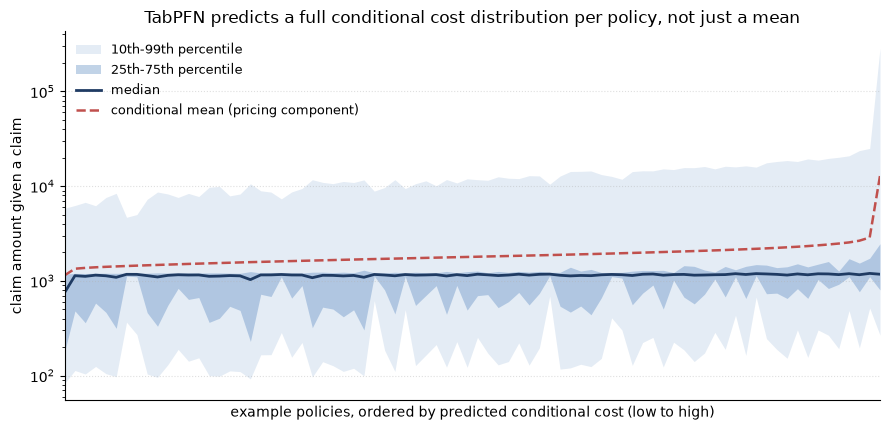

In [14]:
q = np.asarray(dist["quantiles"])                       # (6, len(sel)) quantiles
p10, p25, median, p75, p90, p99 = q
mean = np.asarray(dist["mean"])
x = np.arange(len(sel))

fig, ax = plt.subplots(figsize=(9, 4.4))
ax.fill_between(x, p10, p99, color="#4f81bd", alpha=0.15, lw=0, label="10th-99th percentile")
ax.fill_between(x, p25, p75, color="#4f81bd", alpha=0.35, lw=0, label="25th-75th percentile")
ax.plot(x, median, color="#1f3b63", lw=2, label="median")
ax.plot(x, mean, color="#c0504d", lw=1.8, ls="--", label="conditional mean (pricing component)")

ax.set_yscale("log")
ax.margins(x=0)
ax.set_xticks([])
ax.set_xlabel("example policies, ordered by predicted conditional cost (low to high)")
ax.set_ylabel("claim amount given a claim")
ax.set_title("TabPFN predicts a full conditional cost distribution per policy, not just a mean")
ax.grid(axis="y", ls=":", alpha=0.4)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.legend(frameon=False, fontsize=9, loc="upper left")
plt.tight_layout()
plt.show()

## Optional: matching the GLM on calibration

The two-stage TabPFN *ranks* well but **under-prices the portfolio**: summed over the test set it
charges only ~83% of the actual claim cost. The actuarial GLMs handle the portfolio level more
naturally through their exposure-weighted likelihood and fitted intercept, although their balance
can still depend on the model and regularization.

We can give TabPFN one matching degree of freedom: a **constant factor** = actual claim cost ÷
predicted cost, estimated on a calibration slice held out of training (never the test set). Because it
is a constant, `c · (p × s)` orders policies exactly like `p × s` — so it adjusts the portfolio
*level* without moving the *ranking* one bit.

One TabPFN-specific catch: TabPFN predicts by conditioning on its training rows *in-context*, so it
effectively memorizes them — a policy it saw at fit time gets an unrealistically good prediction.
Estimating the factor on such rows would under-correct, so we re-fit both stages on a subset
(`df_fit`) and score the held-out slice (`df_cal`) they never saw.


In [15]:
# Calibration slice held out of TRAIN (never test); models re-fit WITHOUT it so the
# scored rows were not memorized in-context.
df_fit, df_cal = train_test_split(df_train, test_size=0.1, random_state=RANDOM_STATE)
X_fit = df_fit[tab_features]
X_cal_unit = df_cal[tab_features].copy()
X_cal_unit["Exposure"] = 1.0

clf_cal = TabPFNClassifier(n_estimators=N_ESTIMATORS, ignore_pretraining_limits=True)
clf_cal.fit(X_fit, (df_fit["ClaimAmount"] > 0).astype(int))
p_claim_cal = clf_cal.predict_proba(X_cal_unit)[:, list(clf_cal.classes_).index(1)]

pos_fit = (df_fit["ClaimAmount"] > 0).values
reg_cal = TabPFNRegressor(
    n_estimators=N_ESTIMATORS, ignore_pretraining_limits=True,
    inference_config={"REGRESSION_Y_PREPROCESS_TRANSFORMS": ("1_plus_log",)},
)
reg_cal.fit(X_fit[pos_fit], df_fit.loc[pos_fit, "ClaimAmount"])
severity_cal = reg_cal.predict(X_cal_unit)   # mean; plain predict avoids the full-output row cap

# One constant: actual claim cost / predicted cost on the held-out slice (exposure-weighted).
pp_cal = p_claim_cal * severity_cal
c = df_cal["ClaimAmount"].sum() / (pp_cal * df_cal["Exposure"]).sum()

pp_tabpfn_recal = c * pp_tabpfn                    # constant scaling: Gini unchanged

bal_before = (pp_tabpfn * weight).sum() / (pp_true * weight).sum()
bal_after = (pp_tabpfn_recal * weight).sum() / (pp_true * weight).sum()
print(f"rescale factor c = {c:.3f}")
print(f"portfolio balance (predicted / actual): {bal_before:.3f} -> {bal_after:.3f}")
scores(pp_tabpfn_recal)

rescale factor c = 1.123
portfolio balance (predicted / actual): 0.828 -> 0.930


{'Gini (exposure)  up': 0.33475998106700655,
 'D2 (Tweedie 1.9)  up': 0.012591599713535961,
 'Tweedie dev 1.9  down': 33.917547949405126,
 'Tweedie dev 1.5  down': 76.26418601976408}

The rescale is easiest to see decile by decile: bin the test policies by predicted premium and plot
the predicted premium (x) against the actual claim cost (y) in each bin. **Before**, the low-premium
deciles sit *above* the diagonal — actual cost exceeds what the model charged, i.e. under-pricing —
while the high-premium deciles are already close to it; **after** the single constant factor the
whole curve shifts toward the diagonal, although some decile-level miscalibration remains. The GLM is drawn faintly in both panels for reference, and
the ranking is identical between them — only the level moves.


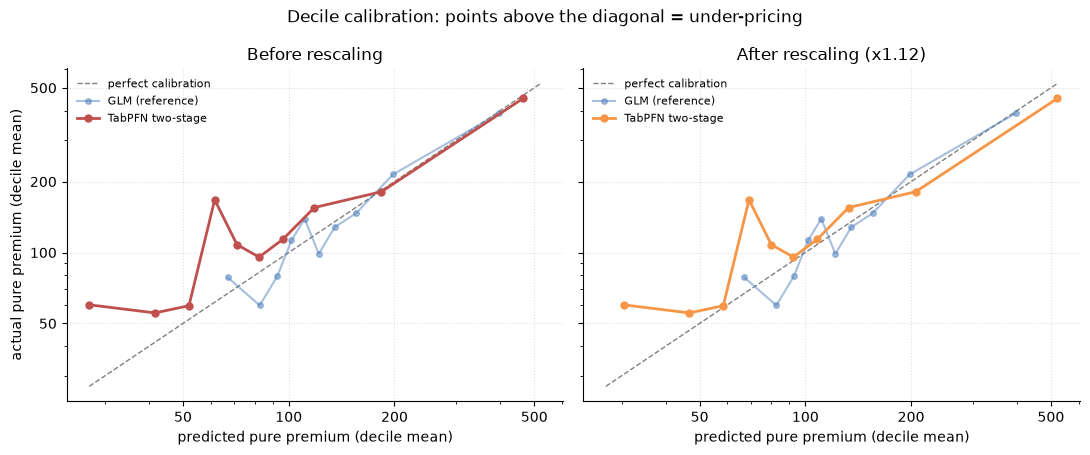

In [16]:
from matplotlib.ticker import ScalarFormatter, NullFormatter, LogLocator


def decile_calibration(pred, n_bins=10):
    order = np.argsort(pred)
    exp = weight[order]
    edges = np.searchsorted(np.cumsum(exp) / exp.sum(), np.linspace(0, 1, n_bins + 1)[1:-1])
    pm, tm = [], []
    for g in np.split(order, edges):
        pm.append(np.average(pred[g], weights=weight[g]))
        tm.append(np.average(pp_true[g], weights=weight[g]))
    return np.clip(pm, 1e-1, None), np.clip(tm, 1e-1, None)

panels = [("Before rescaling", pp_tabpfn, "#c0504d"),
          (f"After rescaling (x{c:.2f})", pp_tabpfn_recal, "#f79646")]
gpm, gtm = decile_calibration(pp_glm_product)            # GLM reference, drawn in both panels
curves = {t: decile_calibration(pred) for t, pred, _ in panels}
allv = np.concatenate([gpm, gtm, *[v for pr in curves.values() for v in pr]])
lo, hi = allv.min(), allv.max()

fig, axes = plt.subplots(1, 2, figsize=(11, 4.6), sharex=True, sharey=True)
for ax, (title, _, color) in zip(axes, panels):
    pm, tm = curves[title]
    ax.plot([lo, hi], [lo, hi], "--", color="grey", lw=1, label="perfect calibration")
    ax.plot(gpm, gtm, "o-", color="#4f81bd", lw=1.5, ms=4, alpha=0.5, label="GLM (reference)")
    ax.plot(pm, tm, "o-", color=color, lw=2, ms=5, label="TabPFN two-stage")
    ax.set(xscale="log", yscale="log", title=title,
           xlabel="predicted pure premium (decile mean)")
    # Adaptive 1-2-5 decade ticks with plain-number labels; suppress crowded minor labels.
    for axis in (ax.xaxis, ax.yaxis):
        axis.set_major_locator(LogLocator(base=10, subs=(1, 2, 5)))
        axis.set_major_formatter(ScalarFormatter())
        axis.set_minor_formatter(NullFormatter())
    ax.grid(ls=":", alpha=0.4)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.legend(frameon=False, fontsize=8, loc="upper left")
axes[0].set_ylabel("actual pure premium (decile mean)")
fig.suptitle("Decile calibration: points above the diagonal = under-pricing")
plt.tight_layout()
plt.show()

## Results

All five models side by side, then the **Lorenz curves** for the ranking view (calibration was
covered in the section above).


In [17]:
table = pd.DataFrame({
    "GLM Tweedie(1.9)": scores(pp_glm_tweedie),
    "GLM Poisson x Gamma": scores(pp_glm_product),
    "TabPFN single-stage": scores(pp_tabpfn_single),
    "TabPFN two-stage": scores(pp_tabpfn),
    "TabPFN two-stage recal.": scores(pp_tabpfn_recal),
})
table.round(4)

,GLM Tweedie(1.9),GLM Poisson x Gamma,TabPFN single-stage,TabPFN two-stage,TabPFN two-stage recal.
Gini (exposure) up,0.2883,0.3057,0.3484,0.3348,0.3348
D2 (Tweedie 1.9) up,0.0137,0.0146,0.0115,0.0088,0.0126
Tweedie dev 1.9 down,33.8783,33.8491,33.9563,34.0479,33.9175
Tweedie dev 1.5 down,76.4087,76.1650,77.0264,76.8858,76.2642


**Lorenz curves.** Policies are sorted safest → riskiest by predicted premium; we plot the cumulative
share of *actual* claim cost against the cumulative share of exposure. A lower, more bowed curve means
better risk separation. Two reference lines frame it: **random** (the diagonal) and the **oracle**
(sorted by realized losses — Gini ~0.98, not 1.0, because claim-bearing policies still occupy a few
percent of the exposure axis). No expected-risk model can reach the oracle: realized claims are mostly
luck, and a model can only rank who is riskier *on average*. The recalibrated two-stage curve overlays
the uncalibrated one exactly — constant rescaling never reorders a single policy.


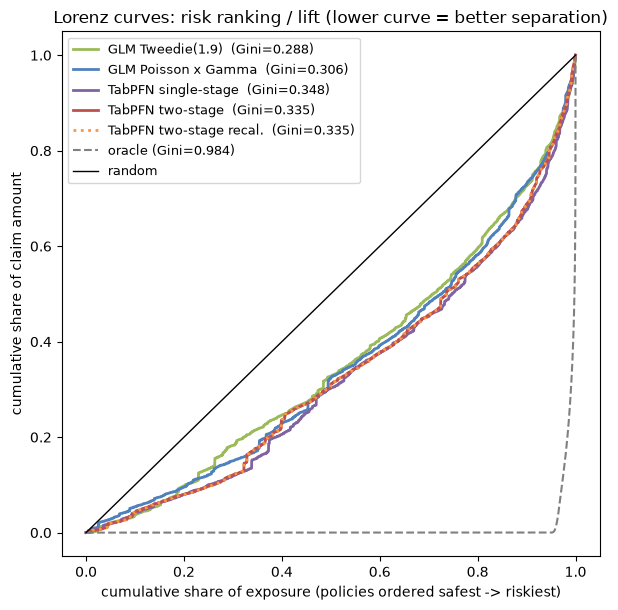

In [18]:
fig, ax = plt.subplots(figsize=(6.2, 6.2))
curves = [
    ("GLM Tweedie(1.9)", pp_glm_tweedie, "#9bbb59", "-"),
    ("GLM Poisson x Gamma", pp_glm_product, "#4f81bd", "-"),
    ("TabPFN single-stage", pp_tabpfn_single, "#8064a2", "-"),
    ("TabPFN two-stage", pp_tabpfn, "#c0504d", "-"),
    # Constant rescaling preserves the ordering, so this overlays two-stage exactly.
    ("TabPFN two-stage recal.", pp_tabpfn_recal, "#f79646", ":"),
]
for label, pred, color, ls in curves:
    order = np.argsort(pred)
    exp = weight[order]
    claim = pp_true[order] * exp
    cx = np.insert(np.cumsum(exp) / exp.sum(), 0, 0)
    cy = np.insert(np.cumsum(claim) / claim.sum(), 0, 0)
    ax.plot(cx, cy, color=color, lw=2, ls=ls,
            label=f"{label}  (Gini={gini_exposure(pp_true, pred, weight):.3f})")

order = np.argsort(pp_true)                          # oracle
exp = weight[order]; claim = pp_true[order] * exp
ax.plot(np.insert(np.cumsum(exp) / exp.sum(), 0, 0),
        np.insert(np.cumsum(claim) / claim.sum(), 0, 0),
        "--", color="grey", label=f"oracle (Gini={gini_exposure(pp_true, pp_true, weight):.3f})")
ax.plot([0, 1], [0, 1], color="black", lw=1, label="random")

ax.set_xlabel("cumulative share of exposure (policies ordered safest -> riskiest)")
ax.set_ylabel("cumulative share of claim amount")
ax.set_title("Lorenz curves: risk ranking / lift (lower curve = better separation)")
ax.legend(loc="upper left", fontsize=9)
plt.tight_layout()
plt.show()

## Takeaways

- **Better ranking, zero feature engineering.** From the raw 9-column dataframe — strings and all, one
  `.fit()` / `.predict()` — TabPFN reaches Gini ~0.34 vs ~0.31 for the best GLM. The GLM needed a
  hand-built 75-column design matrix (binning, one-hot, log-scaling) and several modeling choices to
  get there.
- **A rich conditional cost distribution per policy.** Given a positive claim amount, TabPFN gives
  the conditional mean and quantiles with a shape that varies per policy; the Gamma benchmark has a
  constant-CV distribution.
- **Calibration is a simple adjustment away.** Out of the box TabPFN under-prices the portfolio. A
  single factor estimated on held-out training data improves the balance from ~0.83 to ~0.93 and
  brings Tweedie deviance close to the GLMs, while provably leaving the ranking untouched.
- **The two-stage split is optional for accuracy, essential for the distribution.** With the log
  target transform, a single regressor matches or slightly beats occurrence × conditional aggregate
  cost on both Gini and calibration. The decomposition is what gives you a per-policy conditional
  cost distribution and quantiles.
- **Match the metric to the question.** Judge *ranking* with the exposure-weighted Gini (the headline
  for pricing) and *calibration* with Tweedie deviance / D² and the decile chart. MAE and RMSE are
  actively misleading on a 96%-zero, heavy-tailed target.
